In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Create folders in your Drive
!mkdir -p /content/drive/MyDrive/school-analytics/data/raw
!mkdir -p /content/drive/MyDrive/school-analytics/data/processed

Mounted at /content/drive


In [2]:
!pip install pandas numpy scikit-learn faker matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.4 MB/s eta 0:00:00


In [4]:
!pip install pandas numpy faker scikit-learn

In [5]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()

# Students Table
num_students = 500
students = pd.DataFrame({
    "StudentID": range(1, num_students+1),
    "Name": [fake.name() for _ in range(num_students)],
    "Age": np.random.randint(10, 18, num_students),
    "Class": np.random.choice(["A","B","C","D"], num_students),
    "GradeLevel": np.random.choice(["Year 7","Year 8","Year 9","Year 10"], num_students)
})
students.to_csv("students.csv", index=False)

# Attendance Table
dates = pd.date_range(start="2025-01-01", periods=200)
attendance = []
for student_id in students["StudentID"]:
    for date in dates:
        status = np.random.choice(["Present","Absent"], p=[0.9, 0.1])
        attendance.append([student_id, date, status])
attendance_df = pd.DataFrame(attendance, columns=["StudentID","Date","Status"])
attendance_df.to_csv("attendance.csv", index=False)

# Grades Table
subjects = ["Math","English","Science","History"]
grades = []
for student_id in students["StudentID"]:
    for subject in subjects:
        marks = np.random.randint(50, 100)
        grades.append([student_id, subject, marks])
grades_df = pd.DataFrame(grades, columns=["StudentID","Subject","Marks"])
grades_df.to_csv("grades.csv", index=False)

# Engagement Table
activities = ["Sports","Music","Art","Clubs"]
engagement = []
for student_id in students["StudentID"]:
    for activity in activities:
        score = np.random.randint(1, 10)
        engagement.append([student_id, activity, score])
engagement_df = pd.DataFrame(engagement, columns=["StudentID","Activity","Score"])
engagement_df.to_csv("engagement.csv", index=False)

print("Raw CSVs generated: students.csv, attendance.csv, grades.csv, engagement.csv")

Raw CSVs generated: students.csv, attendance.csv, grades.csv, engagement.csv


In [6]:
# Load raw data
students = pd.read_csv("students.csv")
attendance = pd.read_csv("attendance.csv")
grades = pd.read_csv("grades.csv")
engagement = pd.read_csv("engagement.csv")

# Attendance % per student
attendance_summary = attendance.groupby("StudentID").Status.apply(
    lambda x: (x=="Present").sum()/len(x) * 100
).reset_index().rename(columns={"Status":"AttendancePercent"})

# Average grades per student
grades_summary = grades.groupby("StudentID").Marks.mean().reset_index().rename(columns={"Marks":"AverageMarks"})

# Total engagement score per student
engagement_summary = engagement.groupby("StudentID").Score.sum().reset_index().rename(columns={"Score":"EngagementScore"})

# Merge everything
student_summary = students.merge(attendance_summary, on="StudentID") \
                          .merge(grades_summary, on="StudentID") \
                          .merge(engagement_summary, on="StudentID")

# Save processed CSV
student_summary.to_csv("student_summary.csv", index=False)
print("Processed CSV created: student_summary.csv")

Processed CSV created: student_summary.csv


In [7]:
student_summary['AtRisk'] = ((student_summary['AttendancePercent'] < 80) |
                             (student_summary['AverageMarks'] < 65)).astype(int)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = student_summary[['AttendancePercent','AverageMarks','EngagementScore']]
y = student_summary['AtRisk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       1.00      1.00      1.00        11

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [9]:
import pandas as pd
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feat_importances)

AttendancePercent    0.031579
AverageMarks         0.934192
EngagementScore      0.034229
dtype: float64


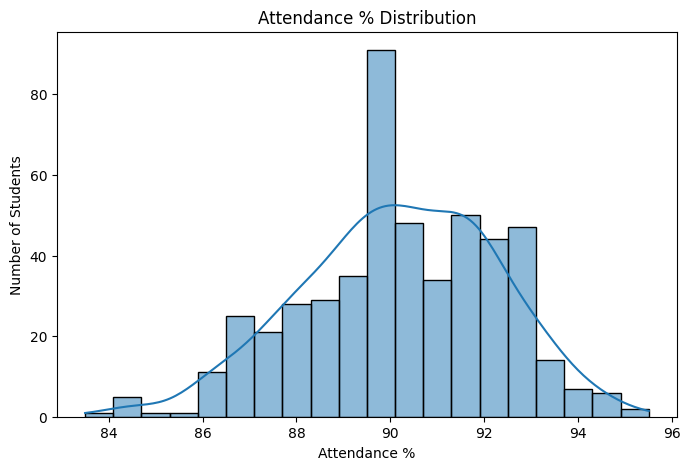

/tmp/ipykernel_56758/355951525.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Class', y='AverageMarks', data=data, ci=None)


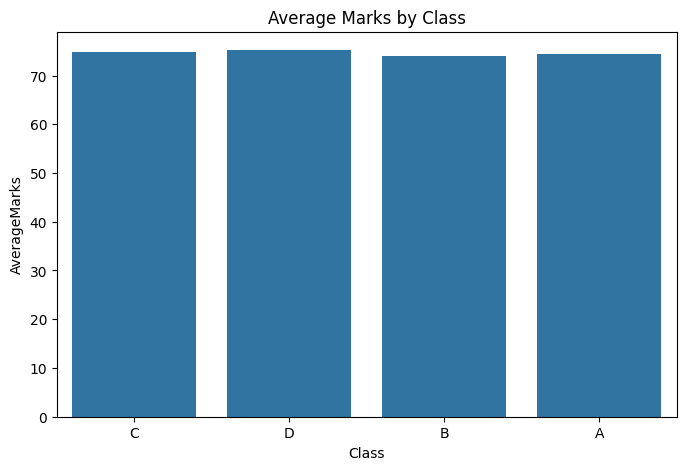

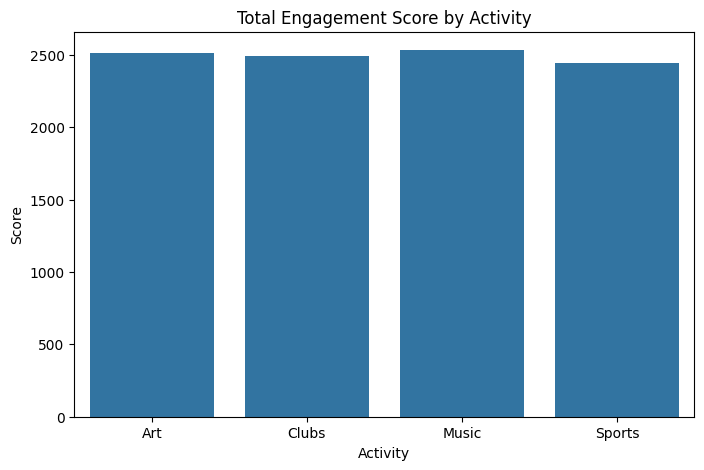

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load processed CSV
data = pd.read_csv("student_summary.csv")

# Attendance distribution
plt.figure(figsize=(8,5))
sns.histplot(data['AttendancePercent'], bins=20, kde=True)
plt.title("Attendance % Distribution")
plt.xlabel("Attendance %")
plt.ylabel("Number of Students")
plt.show()

# Average marks by class
plt.figure(figsize=(8,5))
sns.barplot(x='Class', y='AverageMarks', data=data, ci=None)
plt.title("Average Marks by Class")
plt.show()

# Engagement score by activity (sum)
activity_data = pd.read_csv("engagement.csv")
activity_summary = activity_data.groupby("Activity").Score.sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Activity', y='Score', data=activity_summary)
plt.title("Total Engagement Score by Activity")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define at-risk students
data['AtRisk'] = ((data['AttendancePercent'] < 80) | (data['AverageMarks'] < 65)).astype(int)

# Features and target
X = data[['AttendancePercent','AverageMarks','EngagementScore']]
y = data['AtRisk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       1.00      1.00      1.00        11

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

